In [117]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the dataset
file_path = r'C:\Users\selin\Downloads\archive (2)\cleaned_IoT.csv'
df = pd.read_csv(file_path)



In [118]:

# Display basic info about the dataset
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1048575 non-null  float64
 1   Header_Length    1048575 non-null  float64
 2   Protocol Type    1048575 non-null  float64
 3   Duration         1048575 non-null  float64
 4   Rate             1048575 non-null  float64
 5   Srate            1048575 non-null  float64
 6   Drate            1048575 non-null  float64
 7   fin_flag_number  1048575 non-null  int64  
 8   syn_flag_number  1048575 non-null  int64  
 9   rst_flag_number  1048575 non-null  int64  
 10  psh_flag_number  1048575 non-null  int64  
 11  ack_flag_number  1048575 non-null  int64  
 12  ece_flag_number  1048575 non-null  int64  
 13  cwr_flag_number  1048575 non-null  int64  
 14  ack_count        1048575 non-null  float64
 15  syn_count        1048575 non-null  float64
 16  fin_count        1

In [121]:
# Data Preprocessing
# Check for missing values and handle them (if any)
print("Missing values in dataset:")
print(df.isnull().sum())

# Drop rows with missing values, or you could impute depending on the context
df = df.dropna()

Missing values in dataset:
flow_duration      0
Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
urg_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
Telnet             0
SMTP               0
SSH                0
IRC                0
TCP                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
Weight             0
label  

In [123]:
# Explore the distribution of the 'label' column
print("Distribution of anomaly labels:")
print(df['label'].value_counts())

Distribution of anomaly labels:
label
DDoS-ICMP_Flood            161281
DDoS-UDP_Flood             121205
DDoS-TCP_Flood             101293
DDoS-PSHACK_Flood           92395
DDoS-SYN_Flood              91644
DDoS-RSTFINFlood            90823
DDoS-SynonymousIP_Flood     80680
DoS-UDP_Flood               74787
DoS-TCP_Flood               59807
DoS-SYN_Flood               45207
BenignTraffic               24476
Mirai-greeth_flood          22115
Mirai-udpplain              20166
Mirai-greip_flood           16952
DDoS-ICMP_Fragmentation     10223
MITM-ArpSpoofing             7019
DDoS-ACK_Fragmentation       6431
DDoS-UDP_Fragmentation       6431
DNS_Spoofing                 4034
Recon-HostDiscovery          3007
Recon-OSScan                 2225
Recon-PortScan               1863
DoS-HTTP_Flood               1680
VulnerabilityScan             809
DDoS-HTTP_Flood               626
DDoS-SlowLoris                493
DictionaryBruteForce          324
BrowserHijacking              140
SqlInjecti

In [125]:
# Separate features and labels
X = df.drop(columns=['label'], errors='ignore')
y = df['label'] if 'label' in df.columns else None

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Select features (optional, if you know important ones)
selected_features = X.columns  # or manually select important features

# Use scaled data
X_scaled = pd.DataFrame(X_scaled, columns=selected_features)


In [127]:
# Combine scaled features with the 'label' column if it exists
if 'label' in df.columns:
   X_scaled['label'] = df['label']

print("Scaled dataset:")
print(X_scaled.head())

Scaled dataset:
   flow_duration  Header_Length  Protocol Type  Duration      Rate     Srate  \
0      -0.019434      -0.166254      -0.342740 -0.167194 -0.091697 -0.091697   
1      -0.019434      -0.166247      -0.305814 -0.167194 -0.091658 -0.091658   
2      -0.019434      -0.166369      -0.902229 -0.167194 -0.091366 -0.091366   
3      -0.018328      -0.003045       0.888134 -0.167194 -0.045162 -0.045162   
4      -0.019039      -0.166151      -0.330432 -0.031606 -0.091638 -0.091638   

      Drate  fin_flag_number  syn_flag_number  rst_flag_number  \
0 -0.002126         3.248521        -0.511396         3.168754   
1 -0.002126        -0.307832        -0.511396        -0.315581   
2 -0.002126        -0.307832        -0.511396        -0.315581   
3 -0.002126        -0.307832        -0.511396        -0.315581   
4 -0.002126        -0.307832         1.955433        -0.315581   

   psh_flag_number  ack_flag_number  ece_flag_number  cwr_flag_number  \
0        -0.310829        -0.3759

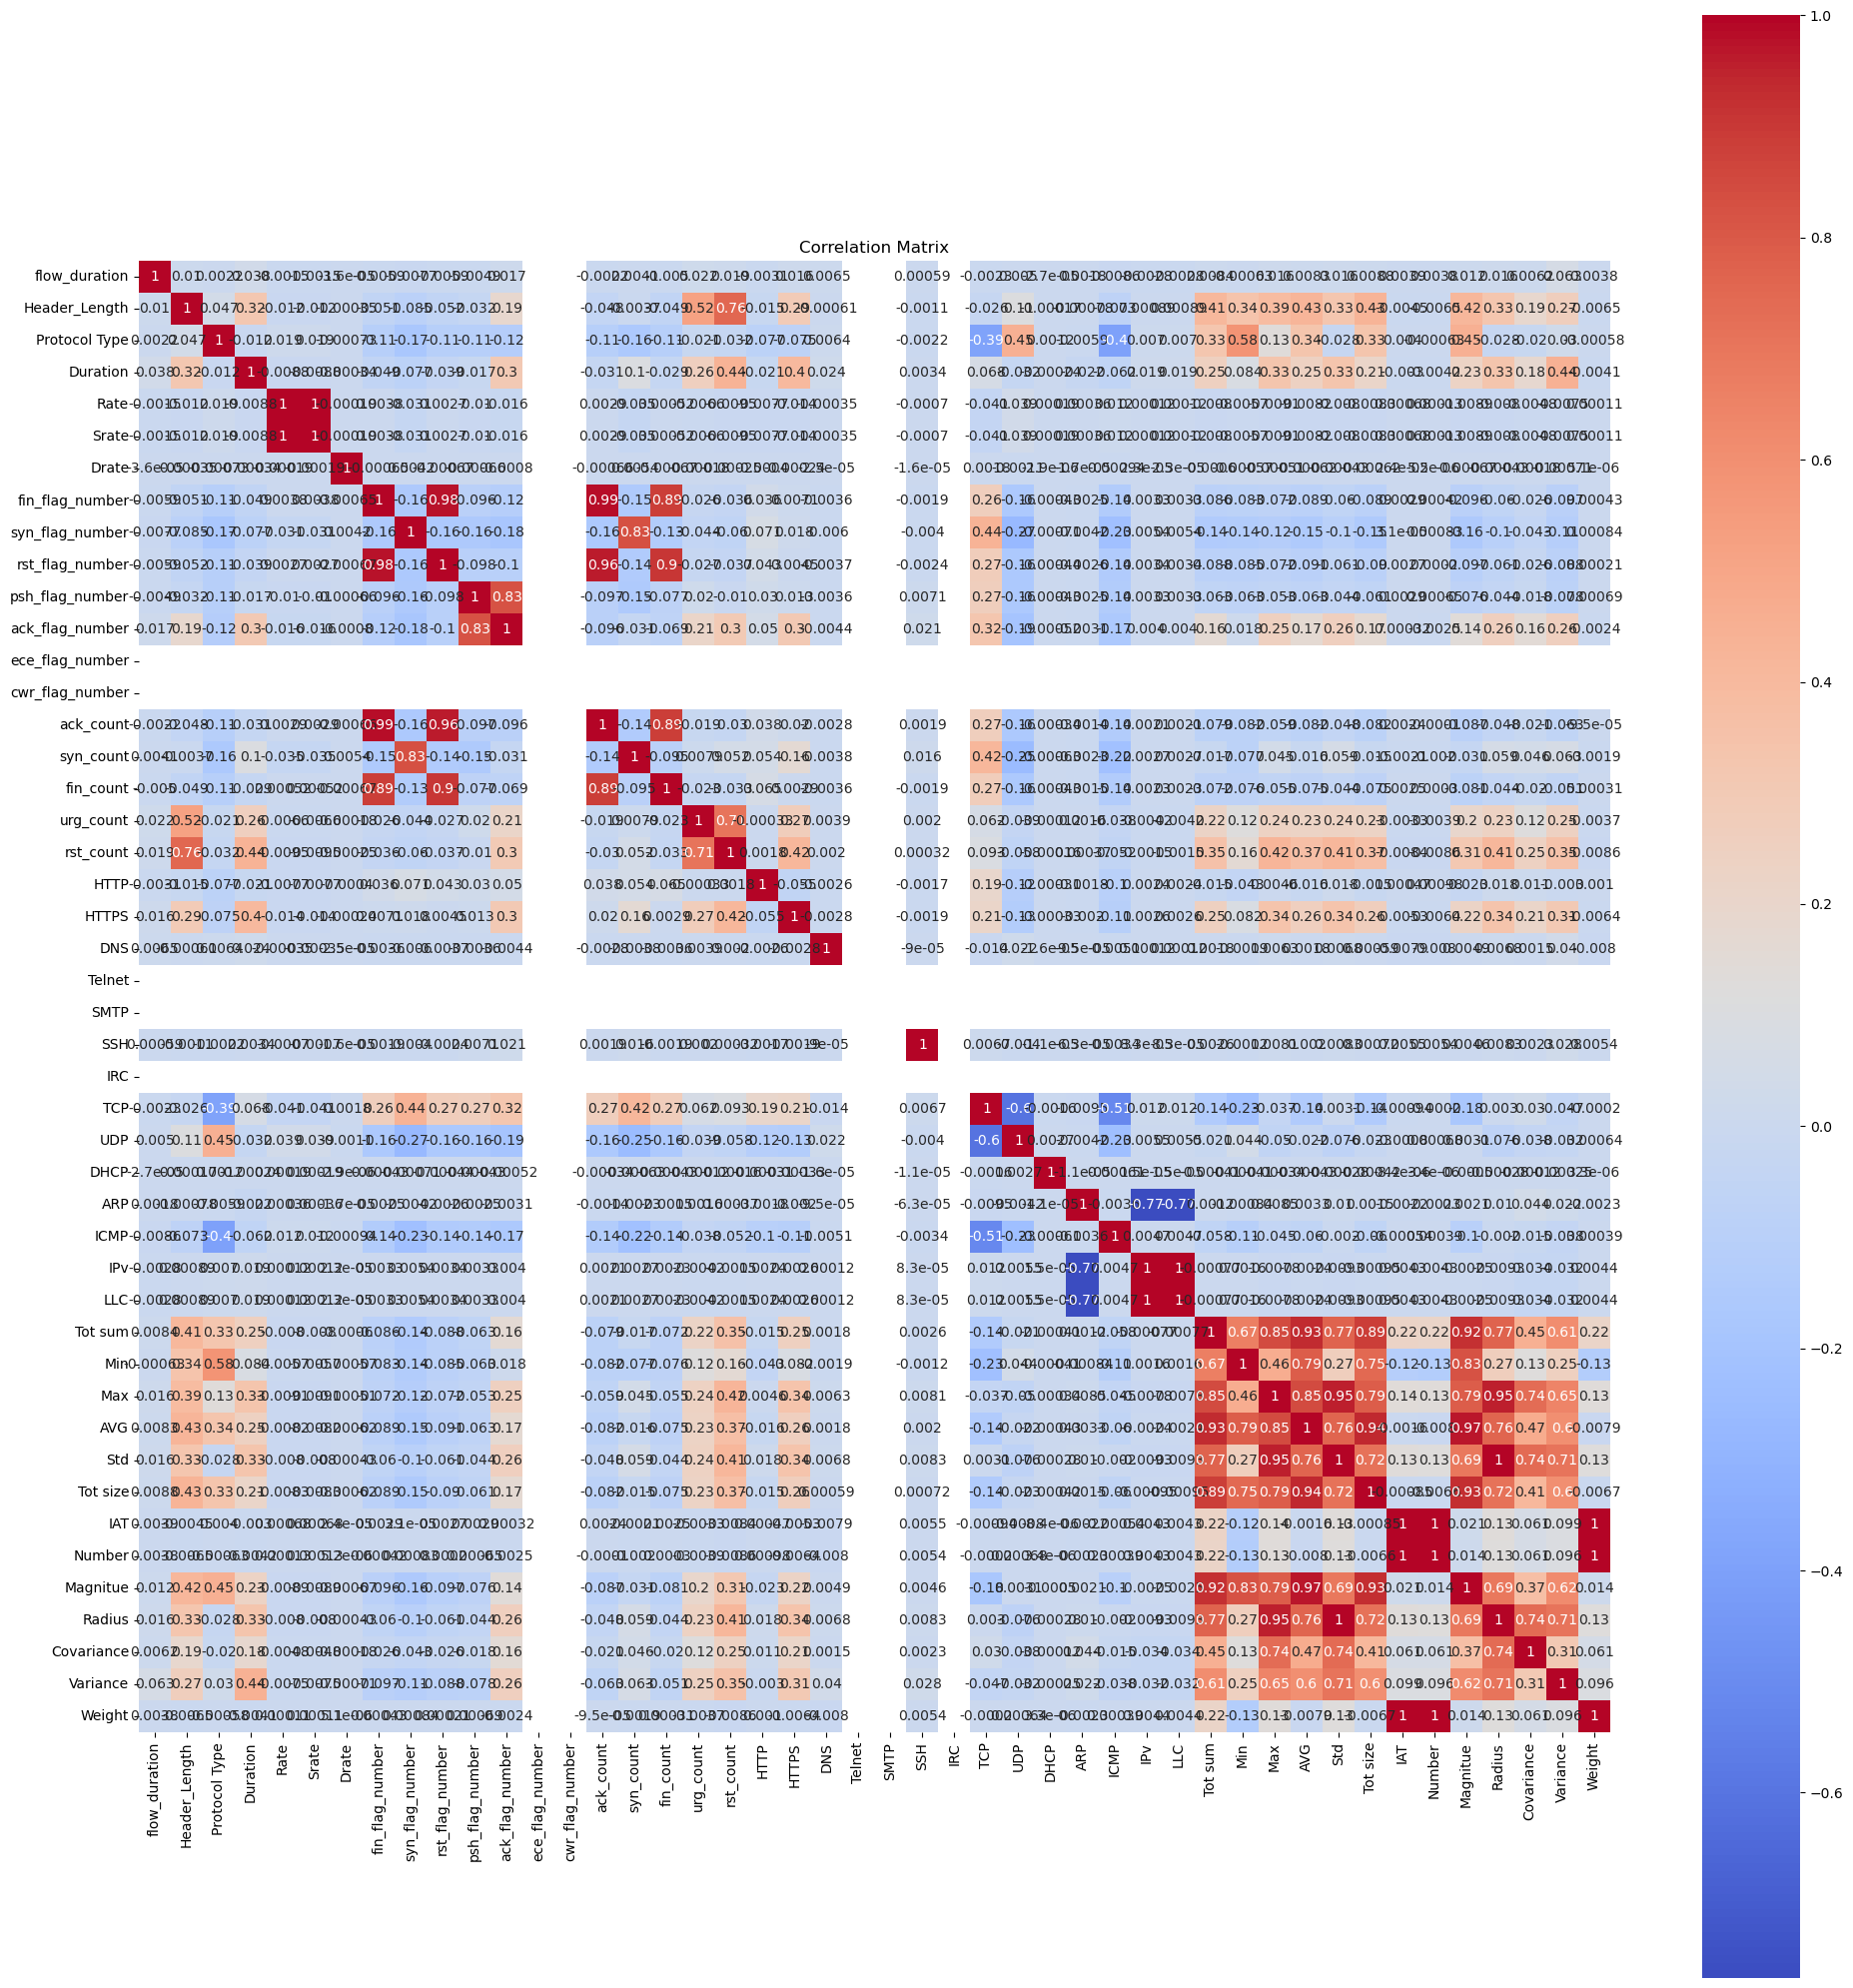

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the correlation matrix (excluding the 'label' column)
corr_matrix = X_scaled.drop('label', axis=1).corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [131]:
print(df.columns)


Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet',
       'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
       'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number',
       'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')


In [133]:
X = df.drop(columns=['label'])  # Features only (no label)
y = df['label']                 # Labels only


In [135]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Now it's purely numbers (floats)


In [137]:
# Create a mask for normal traffic only (for training)
# Assume:
# X_scaled: the scaled full dataset (only features, no labels)
# y: the corresponding labels (strings like 'BenignTraffic', 'DoS', etc.)

if y is not None:
    # Create a mask where traffic is NORMAL ('BenignTraffic')
    mask_normal = (y == 'BenignTraffic')
    
    # Select only normal traffic data
    X_normal = X_scaled[mask_normal]

    # Now split the normal traffic into train/val
    X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

else:
    # No labels, so use all data
    X_train = X_scaled
    X_val = None

# Initialize Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42
)

# Train the model only on normal traffic
iso_forest.fit(X_train)

# Predict on the entire dataset
y_pred = iso_forest.predict(X_scaled)

# Map predictions: -1 => anomaly (1), 1 => normal (0)
y_pred_anomalies = (y_pred == -1).astype(int)

# If true labels exist, evaluate
if y is not None:
    y_true_anomalies = (y != 'BenignTraffic').astype(int)  # 1 for anomalies, 0 for benign

    precision = precision_score(y_true_anomalies, y_pred_anomalies)
    recall = recall_score(y_true_anomalies, y_pred_anomalies)
    f1 = f1_score(y_true_anomalies, y_pred_anomalies)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")


Precision: 0.9955
Recall: 0.4189
F1-score: 0.5897
